In [1]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split, cross_val_predict, KFold
import matplotlib.pyplot as plt

np.random.seed(0)
N = 500

z_temporal = np.random.randn(N)   # sadece zamansal dinamikten çıkarılabilecek bilgi (GRU'nun işi)
z_graph    = np.random.randn(N)   # sadece kanal ilişkisinden çıkarılabilecek bilgi (GAT'ın işi)
z_local    = np.random.randn(N)   # sadece çok-ölçekli segmentlerden çıkarılabilecek bilgi (local branch'in işi)

# Etiket, ÜÇÜNE de bağlı -- ama GRU'nun (z_temporal) ağırlığı en yüksek (makaledeki bulguyu simüle etmek için)
score = 1.0*z_temporal + 0.7*z_graph + 0.5*z_local + 0.6*np.random.randn(N)
y = (score > 0).astype(int)

# Her "gizli sinyal" için gürültülü bir proxy (gerçek modülün onu ne kadar iyi çıkardığını simüle eder)
temporal_feat = z_temporal.reshape(-1,1) + 0.3*np.random.randn(N,3)
graph_feat    = z_graph.reshape(-1,1)    + 0.3*np.random.randn(N,3)
local_feat    = z_local.reshape(-1,1)    + 0.3*np.random.randn(N,3)

print("Şekiller:", temporal_feat.shape, graph_feat.shape, local_feat.shape)

Şekiller: (500, 3) (500, 3) (500, 3)


In [2]:
def simple_cascade(X_train, y_train, X_test, n_layers=3):
    P_prev_train, P_prev_test = None, None
    for l in range(n_layers):
        X_l_train = X_train if l==0 else np.hstack([P_prev_train, X_train])
        X_l_test  = X_test  if l==0 else np.hstack([P_prev_test,  X_test])

        kf = KFold(n_splits=5, shuffle=True, random_state=l)
        learners = [RandomForestClassifier(n_estimators=80, random_state=l),
                    ExtraTreesClassifier(n_estimators=80, random_state=l)]
        oof = np.hstack([cross_val_predict(m, X_l_train, y_train, cv=kf, method="predict_proba") for m in learners])
        fitted = [m.fit(X_l_train, y_train) for m in learners]
        test_p = np.hstack([m.predict_proba(X_l_test) for m in fitted])

        P_prev_train, P_prev_test = oof, test_p
    final_pred = P_prev_test.reshape(-1,2,2).mean(axis=1).argmax(axis=1)
    return final_pred

def single_classifier(X_train, y_train, X_test):
    model = RandomForestClassifier(n_estimators=100, random_state=0)
    model.fit(X_train, y_train)
    return model.predict(X_test)

In [3]:
all_feat = np.hstack([temporal_feat, graph_feat, local_feat])
idx_train, idx_test = train_test_split(np.arange(N), test_size=0.3, random_state=0)

def build_features(include_temporal, include_graph, include_local):
    parts = []
    if include_temporal: parts.append(temporal_feat)
    if include_graph:    parts.append(graph_feat)
    if include_local:    parts.append(local_feat)
    return np.hstack(parts)

conditions = {
    "Full GDF":       (True,True,True,   "cascade"),
    "w/o GRU":        (False,True,True,  "cascade"),   # global'de sadece GAT (graph) kalıyor
    "w/o Global":     (False,False,True, "cascade"),   # hem GRU hem GAT yok
    "w/o Local":      (True,True,False,  "cascade"),
    "w/o Cascade":    (True,True,True,   "single"),
}

results = {}
for name, (t,g,l,clf_type) in conditions.items():
    X = build_features(t,g,l)
    X_tr, X_te = X[idx_train], X[idx_test]
    y_tr, y_te = y[idx_train], y[idx_test]
    if clf_type == "cascade":
        preds = simple_cascade(X_tr, y_tr, X_te)
    else:
        preds = single_classifier(X_tr, y_tr, X_te)
    acc = (preds == y_te).mean()
    results[name] = acc
    print(f"{name:15s} -> Accuracy: {acc:.3f}")

Full GDF        -> Accuracy: 0.773
w/o GRU         -> Accuracy: 0.673
w/o Global      -> Accuracy: 0.567
w/o Local       -> Accuracy: 0.740
w/o Cascade     -> Accuracy: 0.793


In [4]:
full_acc = results["Full GDF"]
print(f"\n{'Koşul':15s} {'ACC':>8s} {'ΔACC':>8s}")
for name, acc in results.items():
    delta = full_acc - acc
    print(f"{name:15s} {acc*100:7.2f}% {delta*100:7.2f}%")


Koşul                ACC     ΔACC
Full GDF          77.33%    0.00%
w/o GRU           67.33%   10.00%
w/o Global        56.67%   20.67%
w/o Local         74.00%    3.33%
w/o Cascade       79.33%   -2.00%


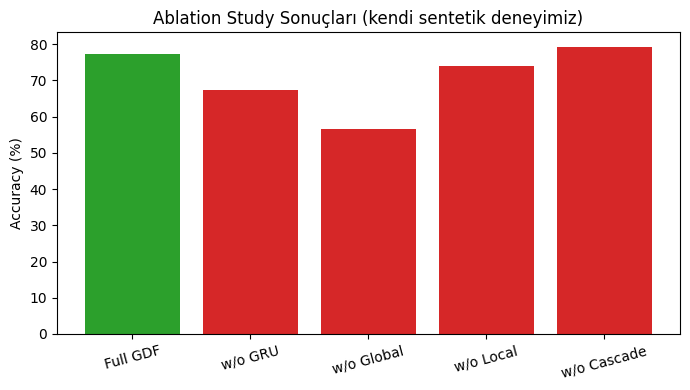

In [5]:
plt.figure(figsize=(7,4))
names = list(results.keys())
accs = [results[n]*100 for n in names]
colors = ['tab:green' if n=="Full GDF" else 'tab:red' for n in names]
plt.bar(names, accs, color=colors)
plt.ylabel("Accuracy (%)")
plt.title("Ablation Study Sonuçları (kendi sentetik deneyimiz)")
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

In [6]:
incremental_conditions = {
    "Sadece rastgele gürültü (temelsiz)": (False, False, False),
    "+ Global (temporal+graph)":           (True, True, False),
    "+ Local":                              (True, True, True),
}
print("--- Artımlı (incremental) ablation -- bizim ek deneyimiz, makalenin kendisi değil ---")
for name, (t,g,l) in incremental_conditions.items():
    if not (t or g or l):
        X = np.random.randn(N, 3)   # hiçbir gerçek sinyal yok, sadece gürültü
    else:
        X = build_features(t,g,l)
    X_tr, X_te = X[idx_train], X[idx_test]
    preds = simple_cascade(X_tr, y[idx_train], X_te)
    acc = (preds == y[idx_test]).mean()
    print(f"{name:35s} -> Accuracy: {acc:.3f}")

--- Artımlı (incremental) ablation -- bizim ek deneyimiz, makalenin kendisi değil ---
Sadece rastgele gürültü (temelsiz)  -> Accuracy: 0.420
+ Global (temporal+graph)           -> Accuracy: 0.740
+ Local                             -> Accuracy: 0.773
